In [1]:
import jax

jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
from numpyro.infer import SVI, Trace_ELBO, init_to_value
from numpyro.infer.autoguide import AutoDelta

# everything from your own package
from cd_dynamax import (
    ContDiscreteNonlinearGaussianSSM,
    adjust_rhs,
    make_optimizer,
    make_key_sequence,
)

from cd_dynamax.src.utils.demo_utils import (
    make_bayesian_nn_drift,
    make_nn_init_dict,
    sample_t_emissions,
    plot_loss_curve,
)

/opt/homebrew/Caskroom/miniconda/base/envs/cd_dynamax-2025-2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Define True Lorenz 63 Drift Function

In [2]:
sigma = 10.0
rho = 28.0
beta = 8.0 / 3.0


def true_drift(x):
    """Lorenz '63 drift function."""
    x1, x2, x3 = x
    dx1 = sigma * (x2 - x1)
    dx2 = x1 * (rho - x3) - x2
    dx3 = x1 * x2 - beta * x3
    return jnp.array([dx1, dx2, dx3])

In [3]:
# System dimensions
state_dim = 3  # Lorenz '63 has 3 state dimensions
emission_dim = 1  # Here we choose to observe only the first dimension
H = jnp.eye(emission_dim, state_dim)

# Noise parameters
diffusion_coeff_true = 1.0
emission_sd_true = 1.0
initial_state_sd_true = 10.0

# Create the SSM
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.

cdnlgssm = ContDiscreteNonlinearGaussianSSM(
    state_dim=state_dim, emission_dim=emission_dim
)

# Build the true parameters using true_drift and known noise params
known_params = {
    "initial_mean": jnp.zeros(state_dim),
    "initial_cov": (initial_state_sd_true**2) * jnp.eye(state_dim),
    "diffusion_coeff": diffusion_coeff_true * jnp.eye(state_dim),
    "emission_function": lambda x: H @ x,
    "emission_cov": (emission_sd_true**2) * jnp.eye(emission_dim),
}
true_params = cdnlgssm.build_params(drift=true_drift, **known_params)

Simulate data using true parameters

[make_t_emissions] Generated 4000 points from 0.0 to 40.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.010000
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


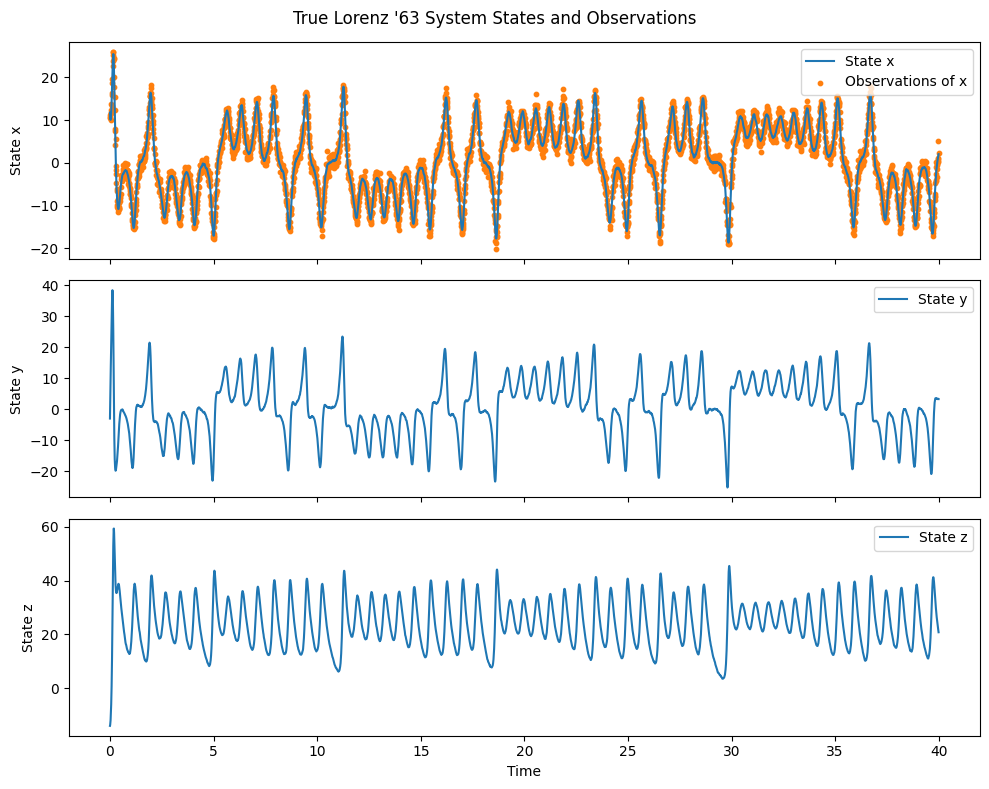

True Log Likelihood: -5978.127158268039


In [4]:
keys = make_key_sequence(0)
t_emissions = sample_t_emissions(
    start=0.0, stop=40.0, dt=0.01, regular=True, key=next(keys)
)

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
state_labels = ["x", "y", "z"]
for i in range(state_dim):
    axs[i].plot(t_emissions, states[:, i], label=f"State {state_labels[i]}", color="C0")
    if i < emission_dim:
        axs[i].scatter(
            t_emissions,
            emissions[:, i],
            label=f"Observations of {state_labels[i]}",
            color="C1",
            s=10,
        )
    axs[i].legend()
    axs[i].set_ylabel(f"State {state_labels[i]}")
axs[-1].set_xlabel("Time")
plt.suptitle("True Lorenz '63 System States and Observations")
plt.tight_layout()
plt.show()

# Compute likelihood of the observed data under the true parameters
filter_settings = {
    "filter_type": "EnKF",
    "filter_state_order": "first",
    "enkf_N_particles": 25,
}
filtered = cdnlgssm.filter(
    params=true_params, t_emissions=t_emissions, emissions=emissions, **filter_settings
)
true_log_likelihood = filtered.marginal_loglik
print(f"True Log Likelihood: {true_log_likelihood}")

Define a numpyro model with a Neural Network based Drift Function (Uniform prior on weights)

In [5]:
nn_hidden_dims = [100]  # single hidden layer with 100 units


def model(t_emissions, emissions=None):
    # Build NN-based drift function (uses GeLU activations)
    drift_base = make_bayesian_nn_drift(
        state_dim=state_dim,
        hidden_dims=nn_hidden_dims,  # single hidden layer with 100 units
        prior="uniform",
        prior_scale=10.0,
    )  # note that this drift takes **kwargs to allow passing known drift-params during predictive calls.
    drift = (
        lambda x: adjust_rhs(x, drift_base(x))
    )  # adjust_rhs truncs the drift to avoid extreme values and has it pointing inward at large radius to prevent divergence in early epochs.

    params = cdnlgssm.build_params(drift=drift, **known_params)

    # Compute (approximate) marginal log likelihood via filtering
    filtered = cdnlgssm.filter(
        params=params,
        emissions=emissions,
        t_emissions=t_emissions,
        **filter_settings,
    )

    # Use the filtering based log likelihood for the model's inference.
    numpyro.factor("log_likelihood", filtered.marginal_loglik)

In [6]:
# SVI
num_steps = 1000

# Define an optimizer (here it is just Adam with fixed learning rate and gradient clipping)
optimizer = make_optimizer(
    initial_learning_rate=0.005,
    # decay_factor=0.5,
    # epochs_per_step=1500,
    # num_epochs=num_steps,
    use_lr_scheduler=0,
    clip_norm=1.0,
)

# Initialize at zero
init_params_dict = make_nn_init_dict(next(keys), state_dim, nn_hidden_dims)

# Now run SVI for MAP inference!
guide = AutoDelta(model, init_loc_fn=init_to_value(values=init_params_dict))
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
svi_result = svi.run(
    next(keys), num_steps=num_steps, t_emissions=t_emissions, emissions=emissions
)

100%|██████████| 1000/1000 [10:46<00:00,  1.55it/s, init loss: 30996.5106, avg. loss [951-1000]: 8140.3718]


Log Prior under uniform prior: -2105.9997883084557


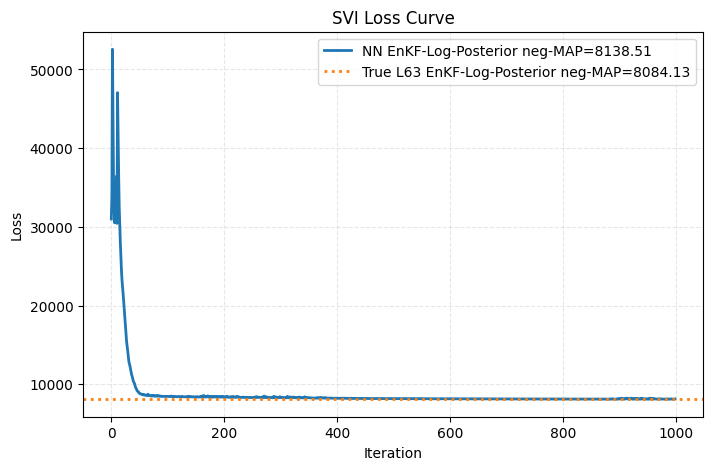

In [7]:
# Plot training curve
# Compute log-prior of uniform prior in 3 => 100 => 3 NN parameter space of [-10, 10]
n_params = (state_dim * nn_hidden_dims[0] + nn_hidden_dims[0]) + (
    nn_hidden_dims[0] * state_dim + state_dim
)
log_prior_uniform = -n_params * jnp.log(
    20.0
)  # since each param has uniform prior over [-10, 10]
print(f"Log Prior under uniform prior: {log_prior_uniform}")
baseline_value = true_log_likelihood + log_prior_uniform
fig = plot_loss_curve(
    svi_result.losses,
    loss_label=f"NN EnKF-Log-Posterior neg-MAP={svi_result.losses[-1]:.2f}",
    baseline_value=-baseline_value,
    baseline_label=f"True L63 EnKF-Log-Posterior neg-MAP={-baseline_value:.2f}",
)
plt.show()

Now, let's extract the MAP-estimated NN drift parameters, and use it for evaluations (short-term forecasting and long-term statistical behavior)

In [8]:
# Build NN-based drift function (uses GeLU activations)
map_drift_base = make_bayesian_nn_drift(
    state_dim=state_dim,
    hidden_dims=nn_hidden_dims,  # single hidden layer with 100 units
    prior="uniform",
    prior_scale=10.0,
    **guide.median(svi_result.params),  # pass in learned params
)  # note that this drift takes **kwargs to allow passing known drift-params during predictive calls.
map_drift = (
    lambda x: adjust_rhs(x, map_drift_base(x))
)  # adjust_rhs truncs the drift to avoid extreme values and has it pointing inward at large radius to prevent divergence in early epochs.

map_params = cdnlgssm.build_params(drift=map_drift, **known_params)

Below, we will generate a new test trajectory from the true model, then do filtering and forecasting (using both true and learned models) to evaluate short-term forecasting performance. Note that the diffusion in the true SDE model (combined with the chaotic sensitivies of the Lorenz drift) makes even high-quality forecasts diverge quickly.

In [9]:
# Now, generate a new testing trajectory from the true model.
# Do filtering then forecasting (using true and learned models)
# to evaluate short-term forecasting performance
test_t_emissions = sample_t_emissions(
    start=0.0, stop=1000.0, dt=0.01, regular=True, key=next(keys)
)

test_states, test_emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(test_t_emissions),
    t_emissions=test_t_emissions,
    transition_type="path",
)

ftf_key = next(keys)


def _filter_and_forecast(
    params, key=ftf_key, T0=70.0, T_filter_end=73.0, T_forecast_end=80.0
):
    # Figure out the time points for filtering
    start_idx_filter = jnp.where(test_t_emissions >= T0)[0][0]
    stop_idx_filter = jnp.where(test_t_emissions >= T_filter_end)[0][0]

    # Figure out the time points for forecasting
    start_idx_forecast = jnp.where(test_t_emissions >= T_filter_end)[0][0]
    stop_idx_forecast = jnp.where(test_t_emissions >= T_forecast_end)[0][0]

    assert start_idx_filter < stop_idx_filter, "Filtering time points are invalid."
    assert start_idx_forecast < stop_idx_forecast, (
        "Forecasting time points are invalid."
    )

    filtered, forecasted = cdnlgssm.filter_and_forecast(
        params=params,
        emissions_filter=test_emissions[start_idx_filter:stop_idx_filter],
        t_emissions_filter=test_t_emissions[start_idx_filter:stop_idx_filter],
        t_emissions_forecast=test_t_emissions[start_idx_forecast:stop_idx_forecast],
        key=key,
    )
    return (
        filtered,
        forecasted,
        start_idx_filter,
        stop_idx_filter,
        start_idx_forecast,
        stop_idx_forecast,
    )


def plot_filter_then_forecast(
    filtered,
    forecasted,
    start_idx_filter,
    stop_idx_filter,
    start_idx_forecast,
    stop_idx_forecast,
    t_emissions=test_t_emissions,
    emissions=test_emissions,
    states=test_states,
    title_suffix="",
):
    fig, axs = plt.subplots(state_dim, 1, figsize=(10, 6), sharex=True)
    for i in range(state_dim):
        # Plot true states
        axs[i].plot(
            t_emissions[start_idx_filter:stop_idx_forecast],
            states[start_idx_filter:stop_idx_forecast, i],
            label=f"True state dim {i}",
            color="C3",
        )

        # Plot filtered means
        filter_times = t_emissions[start_idx_filter:stop_idx_filter]
        axs[i].plot(
            filter_times,
            filtered.filtered_means[:, i],
            label=f"Filtered mean dim {i}",
            color="C0",
        )

        # Plot forecasted means
        forecast_times = t_emissions[start_idx_forecast:stop_idx_forecast]
        axs[i].plot(
            forecast_times,
            forecasted.forecasted_state_means[:, i],
            label=f"Forecasted mean dim {i}",
            color="C2",
        )

        # Plot forecasted uncertainty as shaded region
        forecasted_std = jnp.sqrt(
            jnp.diagonal(forecasted.forecasted_state_covariances, axis1=1, axis2=2)[
                :, i
            ]
        )
        axs[i].fill_between(
            forecast_times.squeeze(),
            forecasted.forecasted_state_means[:, i] - 2 * forecasted_std,
            forecasted.forecasted_state_means[:, i] + 2 * forecasted_std,
            color="C2",
            alpha=0.3,
            label="Forecast ±2 stddev",
        )

        # Note where filtering ends and forecasting begins
        axs[i].axvline(
            x=t_emissions[stop_idx_filter - 1],
            color="k",
            linestyle="--",
            label="Forecast start",
        )

        if i < emission_dim:
            # Plot emissions
            axs[i].scatter(
                t_emissions[start_idx_filter:stop_idx_forecast],
                emissions[start_idx_filter:stop_idx_forecast, i],
                label=f"Observations of dim {i}",
                color="C1",
                s=10,
            )

        axs[i].legend(loc="upper right")
        axs[i].set_ylabel(f"State dim {i}")
    axs[-1].set_xlabel("Time")
    plt.suptitle(f"Filtering and Forecasting Results {title_suffix}")
    plt.tight_layout()
    plt.show()

[make_t_emissions] Generated 100000 points from 0.0 to 1000.0 with avg step ~0.0100
[make_t_emissions] Smallest time step = 0.010000
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


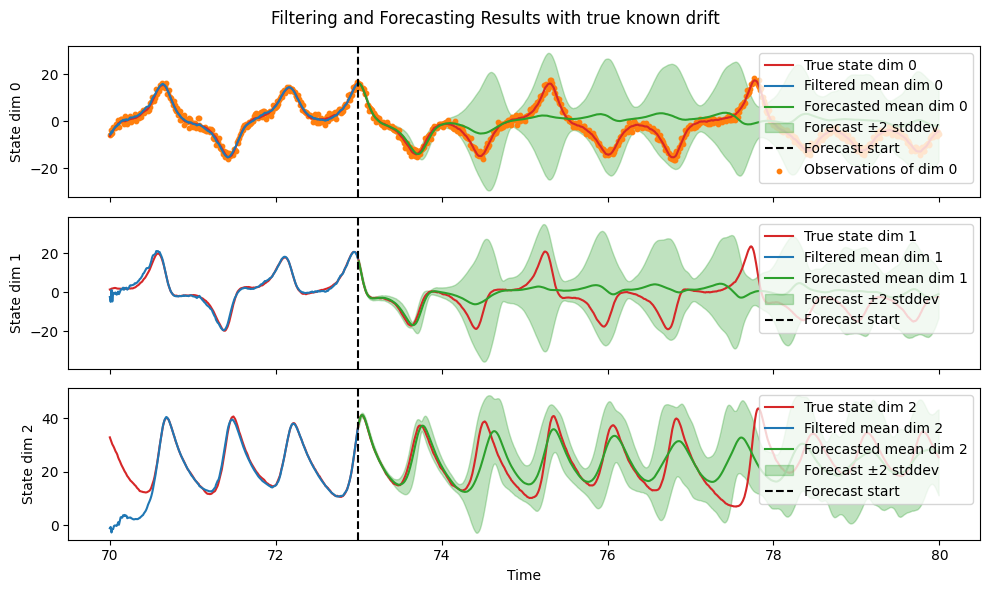

In [10]:
# Filter then forecast using true model
plot_filter_then_forecast(
    *_filter_and_forecast(params=true_params), title_suffix="with true known drift"
)

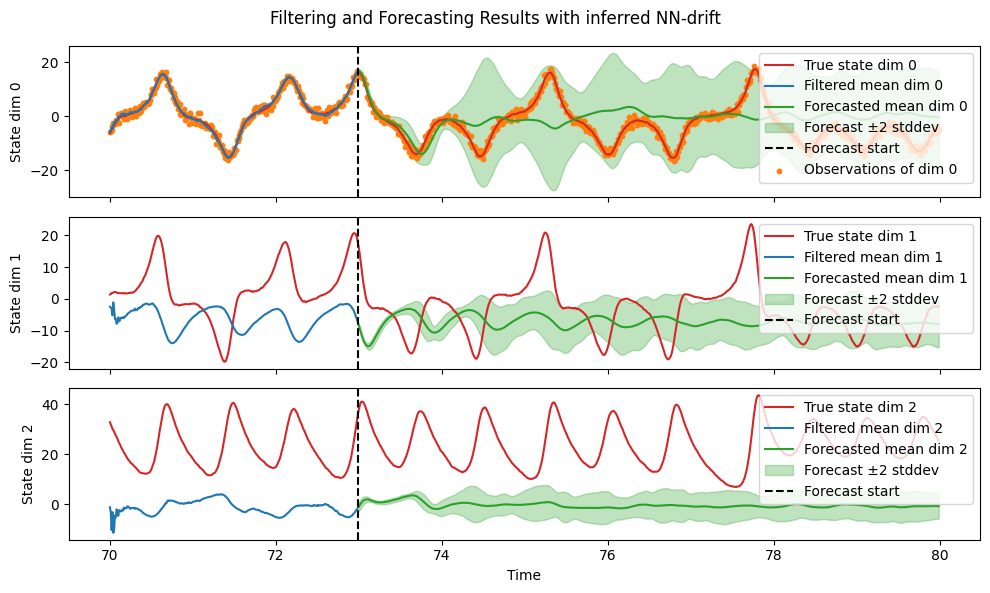

In [11]:
# Filter then forecast using learned Neural SDE map parameters
plot_filter_then_forecast(
    *_filter_and_forecast(params=map_params), title_suffix="with inferred NN-drift"
)

Next, we will look at the long-term statistical behavior of the learned vs true models by simulating a long trajectory from each and plotting histograms. Feel free to compute other things, like Lyapunov exponents, etc.!

In [12]:
long_t_emissions = jnp.arange(start=0.0, stop=1e4, step=0.01).reshape(-1, 1)

# Long simulation with learned parameters
states_learned, emissions_learned = cdnlgssm.sample(
    params=map_params,
    key=next(keys),
    num_timesteps=len(long_t_emissions),
    t_emissions=long_t_emissions,
    transition_type="path",
)

# Long simulation with true parameters for comparison (training data is too short to see true attractor)
states_true_long, emissions_true_long = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(long_t_emissions),
    t_emissions=long_t_emissions,
    transition_type="path",
)

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


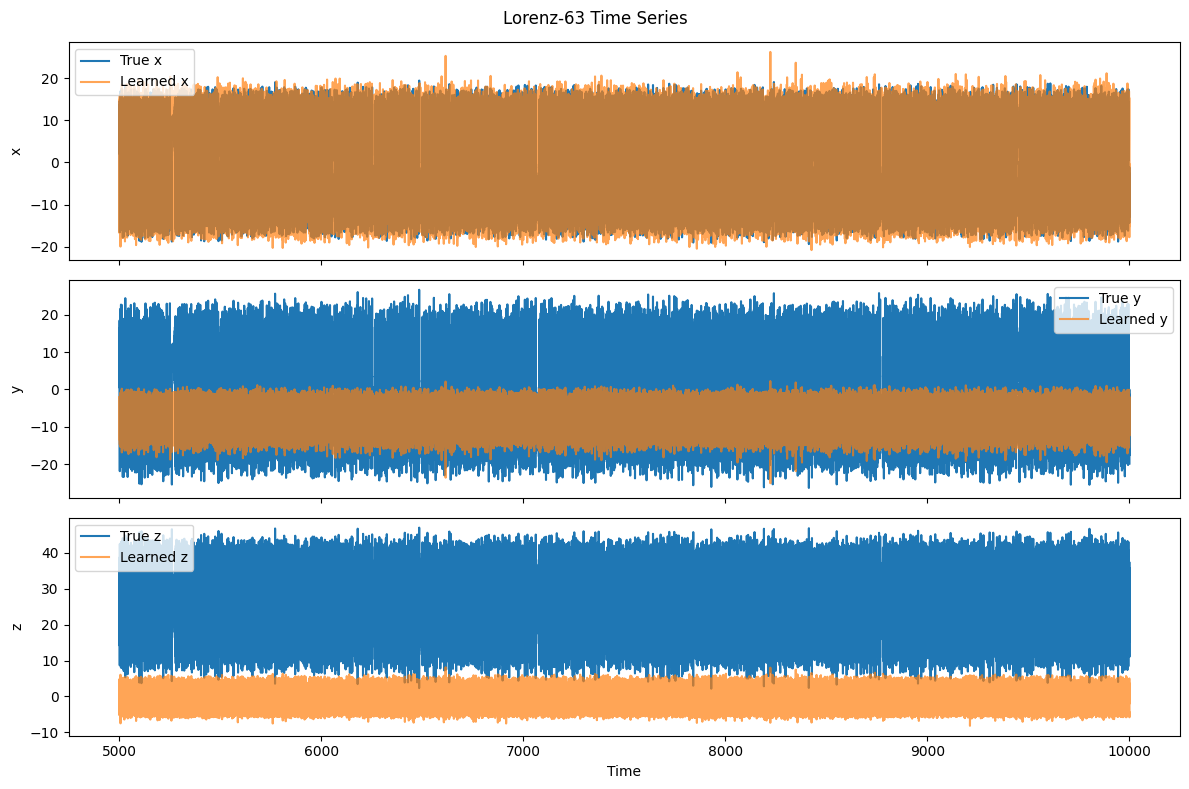

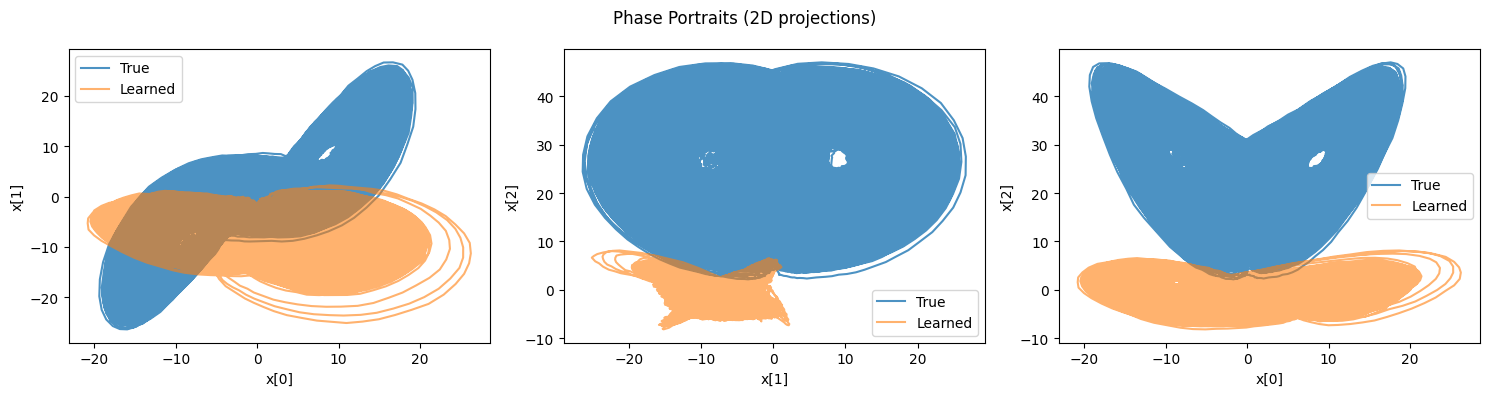

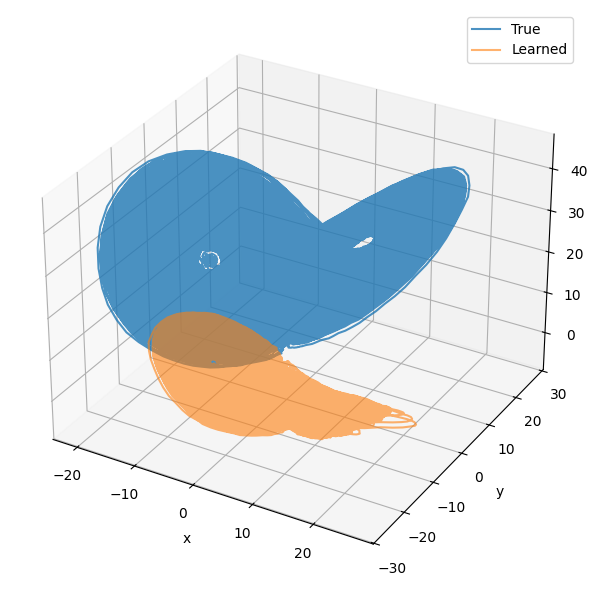

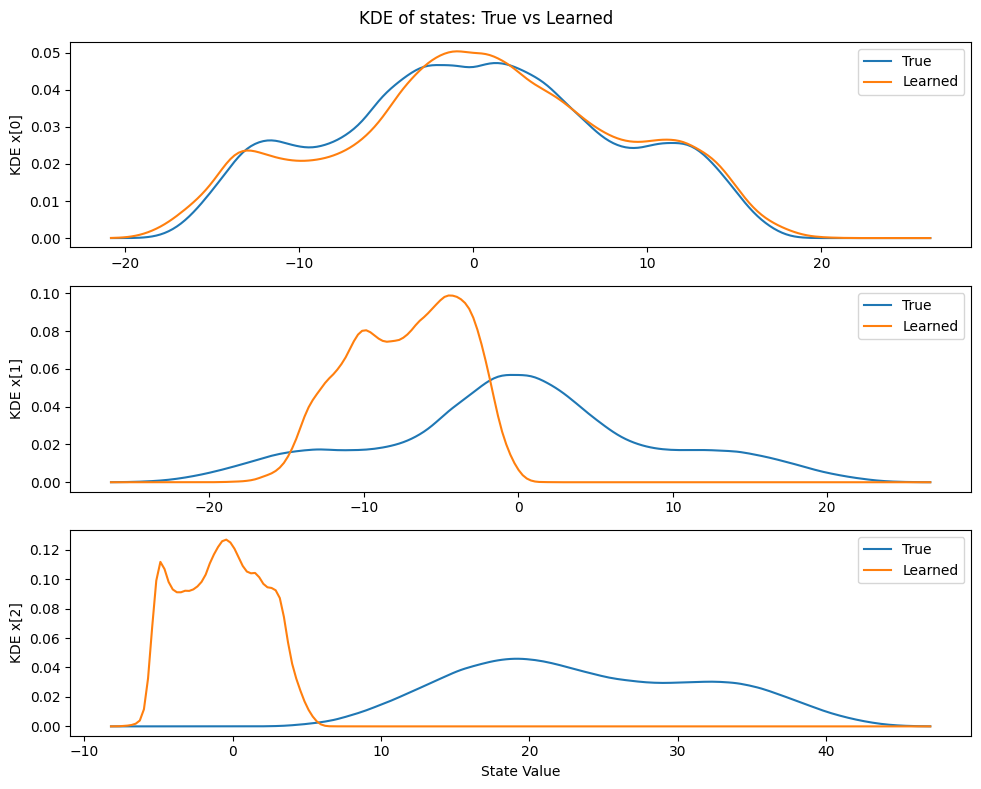

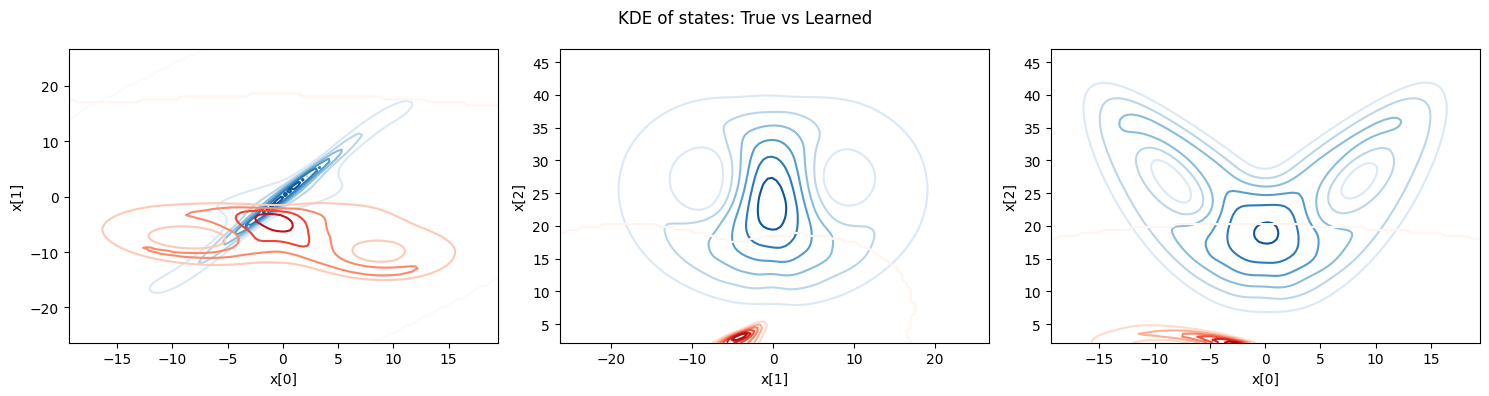

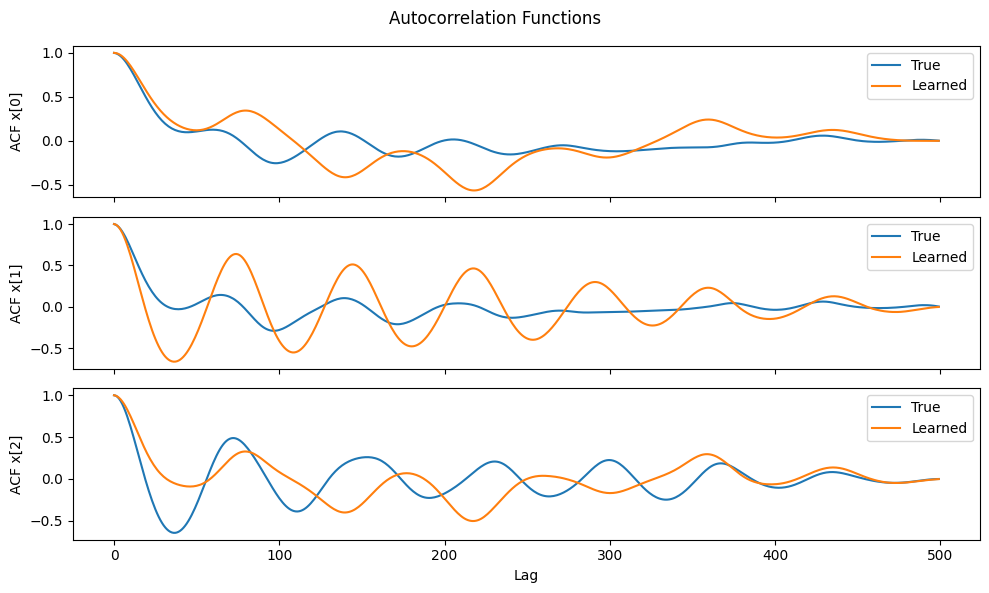

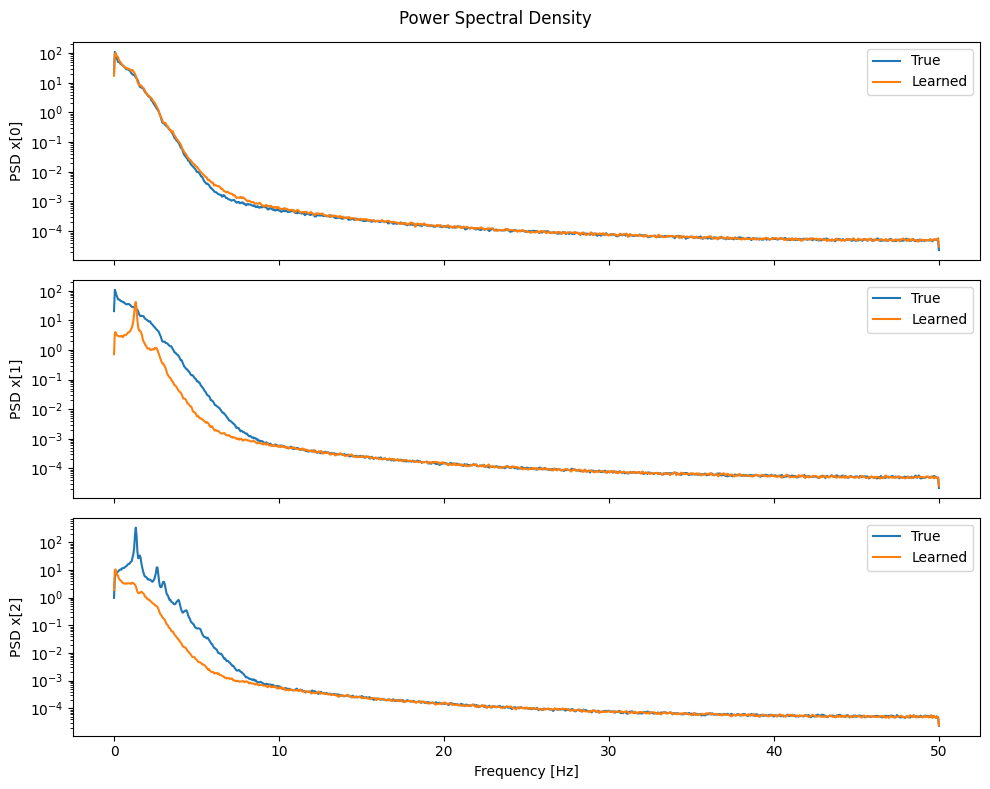

Estimated Largest Lyapunov Exponent:
  True   : 0.996
  Learned: 0.756


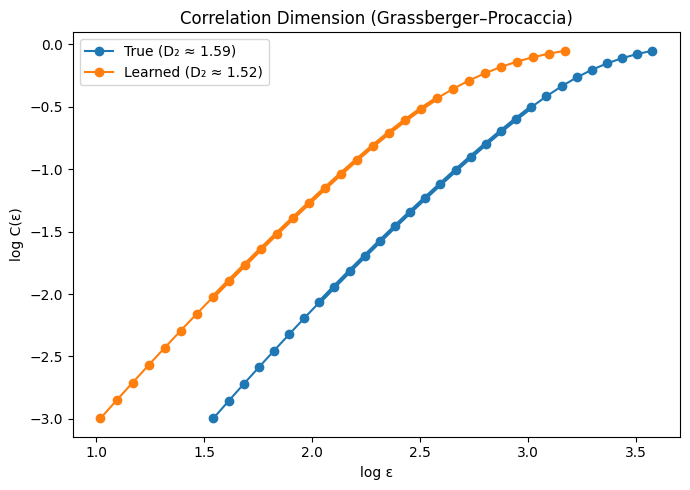

Estimated Correlation Dimension D2:
  True    : 1.587
  Learned : 1.525
Estimated Correlation Dimensions: True D2=1.587, Learned D2=1.525


In [13]:
# Let's plot some analyses
# Note that we don't expect the learned 2nd and 3rd state variables to match-up at all to the true ones.

# We can also get better performance by using a larger training trajectory.
from cd_dynamax.src.utils.plotting_chaos_utils import analyze_chaotic_dynamics

analyze_chaotic_dynamics(
    states_true_long,
    states_learned,
    t=long_t_emissions.squeeze(),
    drift_true=true_drift,
    drift_learn=map_drift,
    burnin_frac=0.5,
)